In this Kernel, I am focusing on exploring the available data, and adjusting SalePrice to inflation

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Imputer
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

from xgboost import XGBRegressor

import os

Notes on things to look into:

  1) Does price take into account inflation? (goes all the way to 1880, which could have a huge effect on the price difference)
  
  2) We did data cleaning on 1 variable, but looking at some other heavily correlated data (to SalePrice), this could be done for more variables, to limit as much as possible the effects of anormal data points

In [2]:
# List of all the functions that we are going to use

def get_rmse(y_predicted,y_real):
    return np.mean(np.sqrt((np.log(y_predicted)-np.log(y_real))**2))

In [3]:
train_data = pd.read_csv('../input/train.csv')
test_data = pd.read_csv('../input/test.csv')

In [4]:
train_data.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [5]:
train_data.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,...,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,...,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,...,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,...,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,...,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,...,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1.5Fin,5,5,1993,1995,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,Wood,Gd,TA,No,GLQ,732,Unf,0,64,796,GasA,...,Y,SBrkr,796,566,0,1362,1,0,1,1,1,1,TA,5,Typ,0,NaN,Attchd,1993.0,Unf,2,480,TA,TA,Y,40,30,0,320,0,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,1Story,8,5,2004,2005,Gable,CompShg,VinylSd,VinylSd,Stone,186.0,Gd,TA,PConc,Ex,TA,Av,GLQ,1369,Unf,0,317,1686,GasA,...,Y,SBrkr,1694,0,0,1694,1,0,2,0,3,1,Gd,7,Typ,1,Gd,Attchd,2004.0,RFn,2,636,TA,TA,Y,255,57,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,PosN,Norm,1Fam,2Story,7,6,1973,1973,Gable,CompShg,HdBoard,HdBoard,Stone,240.0,TA,TA,CBlock,Gd,TA,Mn,ALQ,859,BLQ,32,216,1107,GasA,...,Y,SBrkr,1107,983,0,2090,1,0,2,1,3,1,TA,7,Typ,2,TA,Attchd,1973.0,RFn,2,484,TA,TA,Y,235,204,228,0,0,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Artery,Norm,1Fam,1.5Fin,7,5,1931,1950,Gable,CompShg,BrkFace,Wd Shng,None,0.0,TA,TA,BrkTil,TA,TA,No,Unf,0,Unf,0,952,952,GasA,...,Y,FuseF,1022,752,0,1774,0,0,2,0,2,2,TA,8,Min1,2,TA,Detchd,1931.0,Unf,2,468,Fa,TA,Y,90,0,205,0,0,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,BrkSide,Artery,Artery,2fmCon,1.5Unf,5,6,1939,1950,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,BrkTil,TA,TA,No,GLQ,851,Unf,0,140,991,

(array([ 5.,  0.,  5.,  6.,  6.,  7., 32., 29., 23., 35., 59., 67., 73.,
        92., 89., 91., 62., 60., 57., 73., 67., 54., 45., 33., 30., 31.,
        31., 33., 26., 23., 17., 19., 18., 18., 14., 11.,  5.,  8., 13.,
        12., 10.,  6.,  6.,  5.,  1.,  3.,  5.,  6.,  5.,  4.,  3.,  2.,
         3.,  1.,  3.,  1.,  2.,  2.,  0.,  2.,  0.,  1.,  1.,  0.,  1.,
         0.,  0.,  0.,  0.,  1.,  0.,  0.,  2.,  0.,  0.,  0.,  1.,  0.,
         0.,  0.,  1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  1.]),
 array([ 34900.,  42101.,  49302.,  56503.,  63704.,  70905.,  78106.,
         85307.,  92508.,  99709., 106910., 114111., 121312., 128513.,
        135714., 142915., 150116., 157317., 164518., 171719., 178920.,
        186121., 193322., 200523., 207724., 214925., 222126., 229327.,
        236528., 243729., 250930., 258131., 265332., 272533., 279734.,
        286935., 294136., 301337., 308538., 315739., 322940., 330141.,
        

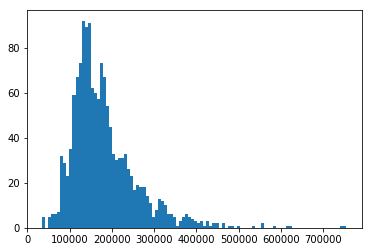

In [6]:
#We want to visualize the dsitribution of our target, here the SalePrice:

plt.hist(train_data.SalePrice, bins=100)

(array([ 2.,  0.,  1.,  1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,
         1.,  2.,  1.,  1.,  3.,  2.,  1.,  1.,  4.,  0.,  1.,  2.,  3.,
        11., 10., 12., 10., 12., 11.,  7., 11., 16., 13., 23., 35., 23.,
        33., 32., 33., 60., 40., 63., 59., 56., 37., 46., 44., 40., 42.,
        61., 47., 48., 43., 35., 29., 28., 27., 29., 29., 37., 14., 25.,
        21., 18., 24., 17.,  6., 10., 19., 15.,  7., 10.,  3.,  4.,  9.,
        10.,  3.,  3.,  4.,  4.,  1.,  3.,  1.,  1.,  0.,  1.,  1.,  1.,
         1.,  0.,  2.,  0.,  0.,  0.,  0.,  0.,  2.]),
 array([10.46024211, 10.49098442, 10.52172673, 10.55246904, 10.58321134,
        10.61395365, 10.64469596, 10.67543827, 10.70618058, 10.73692289,
        10.7676652 , 10.79840751, 10.82914982, 10.85989213, 10.89063444,
        10.92137675, 10.95211906, 10.98286136, 11.01360367, 11.04434598,
        11.07508829, 11.1058306 , 11.13657291, 11.16731522, 11.19805753,
        11.22879984, 11.25954215, 11.29028446, 11.32102677, 11.351769

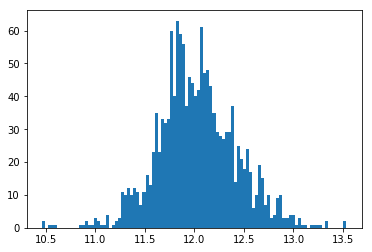

In [7]:
#Data seems very scattered, so we will look at the log ot the Sale Price ditribution:

logged_price = np.log(train_data.SalePrice)
plt.hist(logged_price, bins=100)

(array([  9.,   6.,  37., 122.,  83., 128., 261., 223., 139., 452.]),
 array([1872. , 1885.8, 1899.6, 1913.4, 1927.2, 1941. , 1954.8, 1968.6,
        1982.4, 1996.2, 2010. ]),
 <a list of 10 Patch objects>)

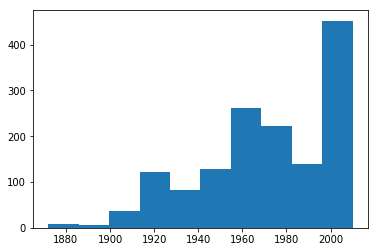

In [8]:
plt.hist(train_data.YearBuilt)

(array([314.,   0., 329.,   0.,   0., 304.,   0., 338.,   0., 175.]),
 array([2006. , 2006.4, 2006.8, 2007.2, 2007.6, 2008. , 2008.4, 2008.8,
        2009.2, 2009.6, 2010. ]),
 <a list of 10 Patch objects>)

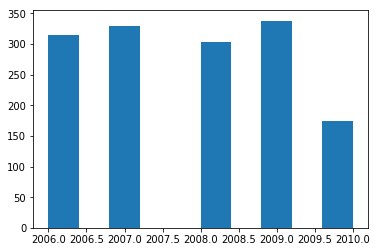

In [9]:
plt.hist(train_data.YrSold)

We can see that the houses have been sold from 2006 to 2010.

From this [website](https://www.in2013dollars.com/1860-dollars-in-2017?amount=1), we can see that from a basis of 1 dollar in 1860, it was 24.29 dollars and 26.17 dollars in 2010. That is on average a 7.74 per cent increase in the value of the dollar, in just those 4 years. The actual change over that period is:

(array([305.,   0., 363.,   0.,   0., 318.,   0., 309.,   0., 164.]),
 array([2006. , 2006.4, 2006.8, 2007.2, 2007.6, 2008. , 2008.4, 2008.8,
        2009.2, 2009.6, 2010. ]),
 <a list of 10 Patch objects>)

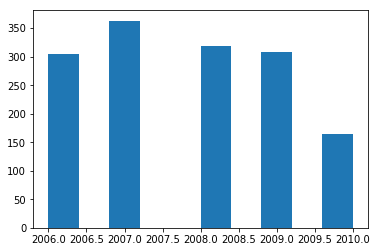

In [10]:
plt.hist(test_data.YrSold)

By looking at the test data, we can see that the 'YrSold' also goes from 2006 to 2010. It seems like it might be interesting to adjust inflation in the test set too.

I simply am not sure if this is something we can do, and if we should to any modifcation to the test set at all? It seems like the proper thing to do too, so I also adjust SalePrice on the test set.

In [11]:
inflation = pd.DataFrame(dict(value_by_1860_usd=[24.29, 24.98, 25.94, 25.85, 26.27],
                          inflation_percent=[3.23, 2.85, 3.84, -0.36, 1.64]) ,
                      index = ['2006', '2007', '2008', '2009', '2010'])
inflation

,value_by_1860_usd,inflation_percent
2006,24.29,3.23
2007,24.98,2.85
2008,25.94,3.84
2009,25.85,-0.36
2010,26.27,1.64


## Now we want to create a new dataset with SalePrice adjusted for inflation. 
Since the lastest year where any house was sold in this data set is 2010, this is what out reference will be. This means we are going to keep the value of the houses sold in 2010, but increase (since inflation devaluates the money) the SalePrice of the other houses.

How to do this:

- Start by creating a new pd.df for each year, containing all the examples that were sold that particular year.
- For each, multiply SalePrice by inflation factor (which has to be 2010_usd/200X_usd (>1, so it will increase the price)) of all examples
- Concat all these pd.df into one, where each will have been adjusted for inflation accordingly
- Check that we have:
    - 1) Same nb of elements in the pd.df
    - 2) Check we have the same nb of examples per year, this should be enough to guarantee enough that we have all the examples

In [12]:
#Let's start by creating a new data set for each year:
infl_df_2006 = train_data.loc[train_data['YrSold'] == 2006]
infl_df_2007 = train_data.loc[train_data['YrSold'] == 2007]
infl_df_2008 = train_data.loc[train_data['YrSold'] == 2008]
infl_df_2009 = train_data.loc[train_data['YrSold'] == 2009]
infl_df_2010 = train_data.loc[train_data['YrSold'] == 2010] #this one will not be changed, just used for final concat

#Since we tried adjusting prices for inflation, and the MAE turned out ot be worse, 
#we are going to try at different % of inflation correction: 25%, 50%, 75% and 100%

#25%
infl_df_2006_25 = infl_df_2006
infl_df_2007_25 = infl_df_2007
infl_df_2008_25 = infl_df_2008
infl_df_2009_25 = infl_df_2009
infl_df_2010_25 = infl_df_2010

#50%
infl_df_2006_50 = infl_df_2006
infl_df_2007_50 = infl_df_2007
infl_df_2008_50 = infl_df_2008
infl_df_2009_50 = infl_df_2009
infl_df_2010_50 = infl_df_2010

#75%
infl_df_2006_75 = infl_df_2006
infl_df_2007_75 = infl_df_2007
infl_df_2008_75 = infl_df_2008
infl_df_2009_75 = infl_df_2009
infl_df_2010_75 = infl_df_2010

infl_df_2006_25.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,...,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,...,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
11,12,60,RL,85.0,11924,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,NridgHt,Norm,Norm,1Fam,2Story,9,5,2005,2006,Hip,CompShg,WdShing,Wd Shng,Stone,286.0,Ex,TA,PConc,Ex,TA,No,GLQ,998,Unf,0,177,1175,GasA,...,Y,SBrkr,1182,1142,0,2324,1,0,3,0,4,1,Ex,11,Typ,2,Gd,BuiltIn,2005.0,Fin,3,736,TA,TA,Y,147,21,0,0,0,0,NaN,NaN,NaN,0,7,2006,New,Partial,345000
17,18,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Sawyer,Norm,Norm,Duplex,1Story,4,5,1967,1967,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,Slab,NaN,NaN,NaN,NaN,0,NaN,0,0,0,GasA,...,Y,SBrkr,1296,0,0,1296,0,0,2,0,2,2,TA,6,Typ,0,NaN,CarPort,1967.0,Unf,2,516,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
20,21,60,RL,101.0,14215,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NridgHt,Norm,Norm,1Fam,2Story,8,5,2005,2006,Gable,CompShg,VinylSd,VinylSd,BrkFace,380.0,Gd,TA,PConc,Ex,TA,Av,Unf,0,Unf,0,1158,1158,GasA,...,Y,SBrkr,1158,1218,0,2376,0,0,3,1,4,1,Gd,9,Typ,1,Gd,BuiltIn,2005.0,RFn,3,853,TA,TA,Y,240,154,0,0,0,0,NaN,NaN,NaN,0,11,2006,New,Partial,325300
28,29,20,RL,47.0,16321,Pave,NaN,IR1,Lvl,AllPub,CulDSac,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1957,1997,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,TA,TA,Gd,BLQ,1277,Unf,0,207,1484,GasA,...,Y,SBrkr,1600,0,0,1600,1,0,1,0,2,1,TA,6,Typ,2,Gd,Attchd,1957.0,RFn,1,319,TA,TA,Y,288,258,0,0,0,0,NaN,NaN,NaN,0,12,2006,WD,Normal,207500


In [13]:
#We get the value of the USD at a given year
usd_2006 = inflation.loc['2006','value_by_1860_usd']
usd_2007 = inflation.loc['2007','value_by_1860_usd']
usd_2008 = inflation.loc['2008','value_by_1860_usd']
usd_2009 = inflation.loc['2009','value_by_1860_usd']

usd_2010 = inflation.loc['2010','value_by_1860_usd']

In [14]:
#We then get a factor of the value of the USD in a year compared to the 2010 USD:
divid_factor_06 = usd_2010 / usd_2006
divid_factor_07 = usd_2010 / usd_2007
divid_factor_08 = usd_2010 / usd_2008
divid_factor_09 = usd_2010 / usd_2009

print('divide factor for 2006 is {} '.format(divid_factor_06))
print('divide factor for 2007 is {} '.format(divid_factor_07))
print('divide factor for 2008 is {} '.format(divid_factor_08))
print('divide factor for 2009 is {} '.format(divid_factor_09))

#25%:
divid_factor_06_25 = divid_factor_06/4
divid_factor_07_25 = divid_factor_07/4
divid_factor_08_25 = divid_factor_08/4
divid_factor_09_25 = divid_factor_09/4

#50%
divid_factor_06_50 = divid_factor_06/2
divid_factor_07_50 = divid_factor_07/2
divid_factor_08_50 = divid_factor_08/2
divid_factor_09_50 = divid_factor_09/2

#75%
divid_factor_06_75 = divid_factor_06/(4/3)
divid_factor_07_75 = divid_factor_07/(4/3)
divid_factor_08_75 = divid_factor_08/(4/3)
divid_factor_09_75 = divid_factor_09/(4/3)

float(divid_factor_06)

divide factor for 2006 is 1.0815150267599836 
divide factor for 2007 is 1.0516413130504403 
divide factor for 2008 is 1.01272166538165 
divide factor for 2009 is 1.016247582205029 


1.0815150267599836

In [15]:
#We need to multiply the values of SalePrice by divid_factor

#25%:
infl_df_2006_25['SalePrice'] = infl_df_2006_25['SalePrice'].apply(lambda x: x*float(divid_factor_06_25));
infl_df_2007_25['SalePrice'] = infl_df_2007_25['SalePrice'].apply(lambda x: x*divid_factor_07_25);
infl_df_2008_25['SalePrice'] = infl_df_2008_25['SalePrice'].apply(lambda x: x*divid_factor_08_25);
infl_df_2009_25['SalePrice'] = infl_df_2009_25['SalePrice'].apply(lambda x: x*divid_factor_09_25);

#50%:
infl_df_2006_50['SalePrice'] = infl_df_2006['SalePrice'].apply(lambda x: x*divid_factor_06_50);
infl_df_2007_50['SalePrice'] = infl_df_2007['SalePrice'].apply(lambda x: x*divid_factor_07_50);
infl_df_2008_50['SalePrice'] = infl_df_2008['SalePrice'].apply(lambda x: x*divid_factor_08_50);
infl_df_2009_50['SalePrice'] = infl_df_2009['SalePrice'].apply(lambda x: x*divid_factor_09_50);

#75%:
infl_df_2006_75['SalePrice'] = infl_df_2006['SalePrice'].apply(lambda x: x*divid_factor_06_75);
infl_df_2007_75['SalePrice'] = infl_df_2007['SalePrice'].apply(lambda x: x*divid_factor_07_75);
infl_df_2008_75['SalePrice'] = infl_df_2008['SalePrice'].apply(lambda x: x*divid_factor_08_75);
infl_df_2009_75['SalePrice'] = infl_df_2009['SalePrice'].apply(lambda x: x*divid_factor_09_75);

#100%:
infl_df_2006['SalePrice'] = infl_df_2006['SalePrice'].apply(lambda x: x*divid_factor_06);
infl_df_2007['SalePrice'] = infl_df_2007['SalePrice'].apply(lambda x: x*divid_factor_07);
infl_df_2008['SalePrice'] = infl_df_2008['SalePrice'].apply(lambda x: x*divid_factor_08);
infl_df_2009['SalePrice'] = infl_df_2009['SalePrice'].apply(lambda x: x*divid_factor_09);

/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  after removing the cwd from sys.path.
/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  """
/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-d

In [16]:
#Now we need to concat all the sub DataFrames in one bigger one
#25%:
frames_25 = [infl_df_2006_25, infl_df_2007_25, infl_df_2008_25, infl_df_2009_25, infl_df_2010_25]
infl_train_data_25 = pd.concat(frames_25)

#50%:
frames_50 = [infl_df_2006_50, infl_df_2007_50, infl_df_2008_50, infl_df_2009_50, infl_df_2010_50]
infl_train_data_50 = pd.concat(frames_50)

#75%:
frames_75 = [infl_df_2006_75, infl_df_2007_75, infl_df_2008_75, infl_df_2009_75, infl_df_2010_75]
infl_train_data_75 = pd.concat(frames_75)

#100:
frames = [infl_df_2006, infl_df_2007, infl_df_2008, infl_df_2009, infl_df_2010]
infl_train_data = pd.concat(frames)


print('size of train data : ',train_data.size)
print('size of train data adjusted for inflation : ', infl_train_data.size)

size of train data :  118260
size of train data adjusted for inflation :  118260


We have now created the same DataFrame, but with SalePrice adjusted for inflation. We can see that both 'train_data' and the adjusted for inflation DataFrame have the same size. The other difference is that they are not arranged in the same order, as the adjusted is order by 'YrSold', as it is a concat of sub-DataFrames divided by year

In [17]:
print('nb of missing data = {0}'.format(train_data.isnull().sum().max()))

nb of missing data = 1453


In [18]:
#Missing values:
total = train_data.isnull().sum().sort_values(ascending=False)
percent=(train_data.isnull().sum()/train_data.isnull().count()).sort_values(ascending=False)

missing_data=pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(20)

,Total,Percent
PoolQC,1453,0.995205
MiscFeature,1406,0.963014
Alley,1369,0.937671
Fence,1179,0.807534
FireplaceQu,690,0.472603
LotFrontage,259,0.177397
GarageCond,81,0.055479
GarageType,81,0.055479
GarageYrBlt,81,0.055479
GarageFinish,81,0.055479


After looking at this information, we can see that:
- 'PoolQc', 'MiscFeature', 'Alley', and 'Fence'are lacking from 99 tp 80% of their data. No real point in keeping that sort of data, we could just dump it, it will only make out database bigger for nothing to use dummies here.
- All the 'Garage[...]' features seem to have the same data lacking. Later on, with the histrogram they look very correlated. We could keep only one of them maybe? 
- Same goes for 'Bsmt[...]' data.

In the [Kernel](http://www.kaggle.com/pmarcelino/comprehensive-data-exploration-with-python) most of this is based on, dummies are the last step. I guess this is once everything has already been smoothed out, which sounds (more) logical

In [19]:
correlation = train_data.corr()
print('Most correlated columns to {0} are: '.format('SalePrice'),'\n', correlation['SalePrice'].sort_values(ascending = False)[:10])
print('Least correlated columns to {0} are: '.format('SalePrice'),'\n', correlation['SalePrice'].sort_values(ascending = False)[-10:])

Most correlated columns to SalePrice are:  
 SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64
Least correlated columns to SalePrice are:  
 BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64


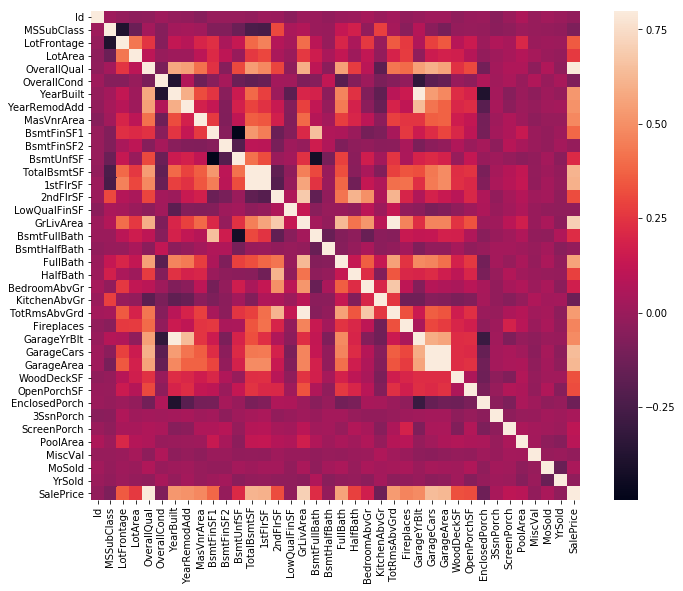

In [20]:
corrmat = train_data.corr()
f, ax = plt.subplots(figsize=(12,9))
sns.heatmap(corrmat, vmax = 0.8, square=True)

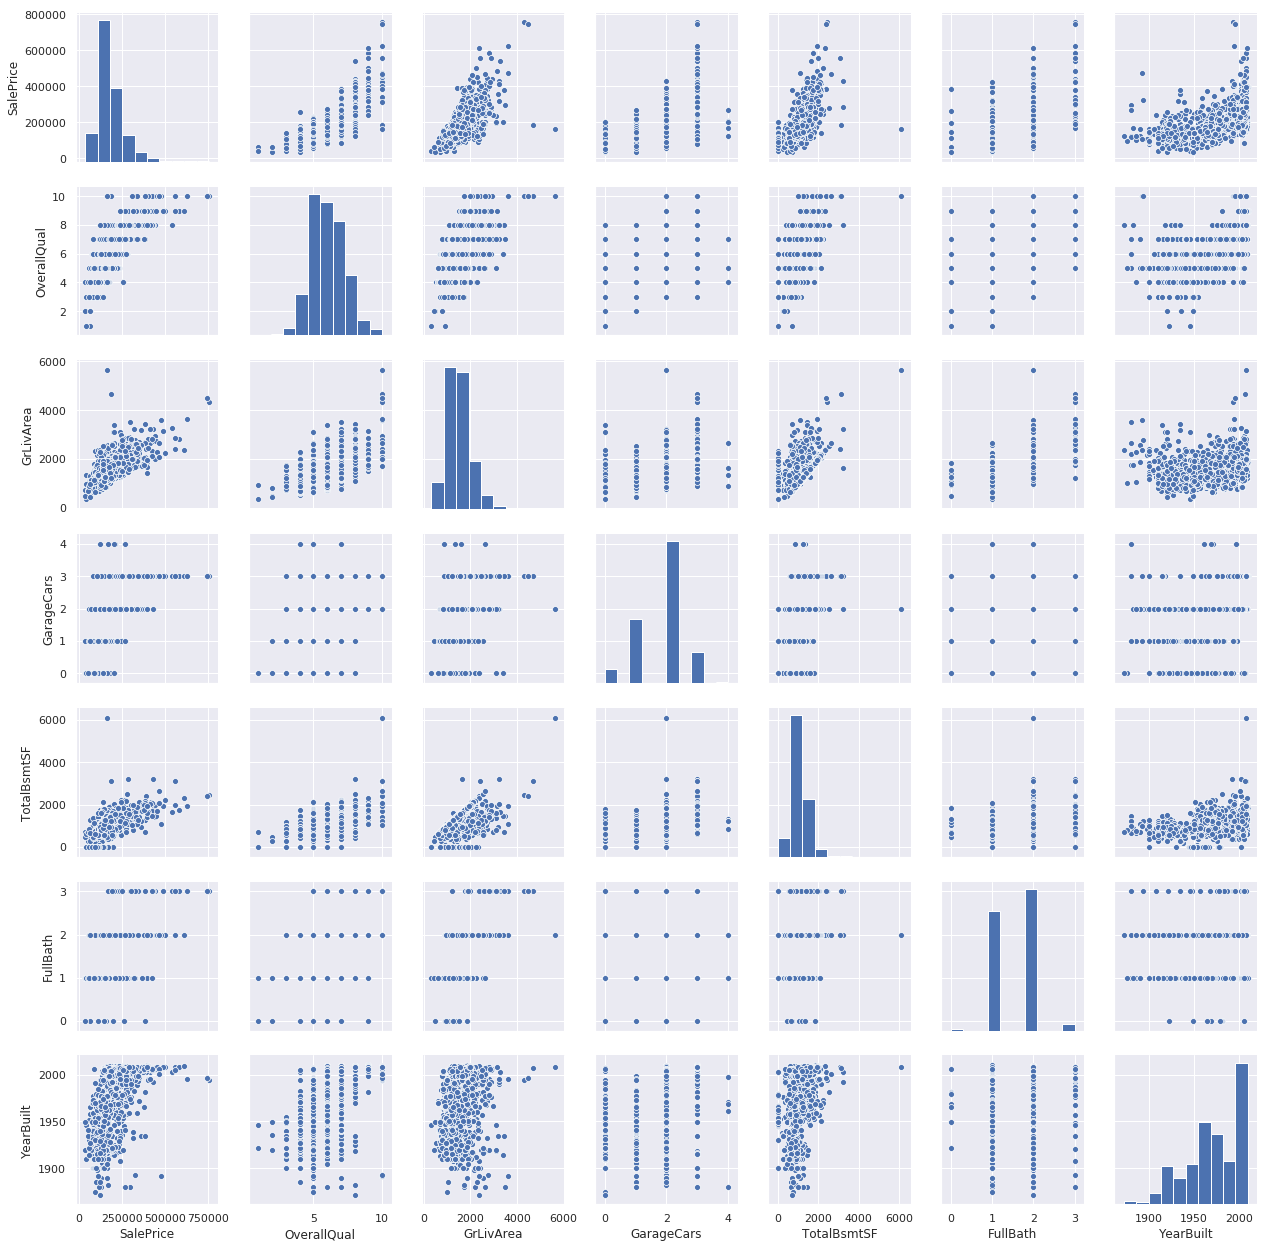

In [21]:
#Scatterplot
sns.set()
cols_scat = ['SalePrice','OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']
sns.pairplot(train_data[cols_scat])
plt.show()

In [22]:
#Now, we get rid of variables that are missing too much data (here, everything that is missing more than 1 variable)
train_data = train_data.drop((missing_data[missing_data['Total']>1]).index, 1)
infl_train_data = infl_train_data.drop((missing_data[missing_data['Total']>1]).index, 1)
infl_train_data_25 = infl_train_data_25.drop((missing_data[missing_data['Total']>1]).index, 1)
infl_train_data_50 = infl_train_data_50.drop((missing_data[missing_data['Total']>1]).index, 1)
infl_train_data_75 = infl_train_data_75.drop((missing_data[missing_data['Total']>1]).index, 1)

#We will delete the entry containing the missing data in the Electrical variable: 
train_data = train_data.drop(train_data.loc[train_data['Electrical'].isnull()].index)
infl_train_data = infl_train_data.drop(infl_train_data.loc[infl_train_data['Electrical'].isnull()].index)
infl_train_data_25 = infl_train_data_25.drop(infl_train_data_25.loc[infl_train_data_25['Electrical'].isnull()].index)
infl_train_data_50 = infl_train_data_50.drop(infl_train_data_50.loc[infl_train_data_50['Electrical'].isnull()].index)
infl_train_data_75 = infl_train_data_75.drop(infl_train_data_75.loc[infl_train_data_75['Electrical'].isnull()].index)

We should look more into the details of the data before deleting it, we should not base ourselves on the conclusions that we think might explain the irregularity of the data. Especially before deleting that data.

In [23]:
print('Missing values in train data : ', train_data.isnull().sum().max())
print('Missing values in train data adjusted for inflation : ', infl_train_data.isnull().sum().max())

Missing values in train data :  0
Missing values in train data adjusted for inflation :  0


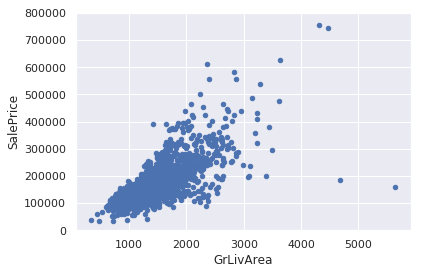

In [24]:
var = 'GrLivArea'
data = pd.concat([train_data['SalePrice'], train_data[var]], axis=1)
data.plot.scatter(x=var, y='SalePrice', ylim=(0,800000))

In [25]:
#We want to see the two points with highest GrLivArea, they seem ourliers
train_data.sort_values(by = 'GrLivArea', ascending = False)[:2] #(from kernel found online)

#I just checked if another technique worked, just for pratcise, it gives the same result (which is good news)
#High_GrLivArea = train_data[train_data['GrLivArea']>4500]
#High_GrLivArea.head()

,Id,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,ExterQual,ExterCond,Foundation,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageCars,GarageArea,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1298,1299,60,RL,63887,Pave,IR3,Bnk,AllPub,Corner,Gtl,Edwards,Feedr,Norm,1Fam,2Story,10,5,2008,2008,Hip,ClyTile,Stucco,Stucco,Ex,TA,PConc,5644,0,466,6110,GasA,Ex,Y,SBrkr,4692,950,0,5642,2,0,2,1,3,1,Ex,12,Typ,3,2,1418,Y,214,292,0,0,0,480,0,1,2008,New,Partial,160000
523,524,60,RL,40094,Pave,IR1,Bnk,AllPub,Inside,Gtl,Edwards,PosN,PosN,1Fam,2Story,10,5,2007,2008,Hip,CompShg,CemntBd,CmentBd,Ex,TA,PConc,2260,0,878,3138,GasA,Ex,Y,SBrkr,3138,1538,0,4676,1,0,3,1,3,1,Ex,11,Typ,1,3,884,Y,208,406,0,0,0,0,0,10,2007,New,Partial,184750


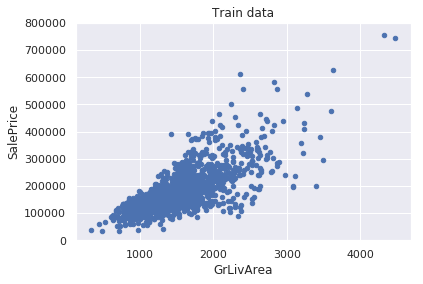

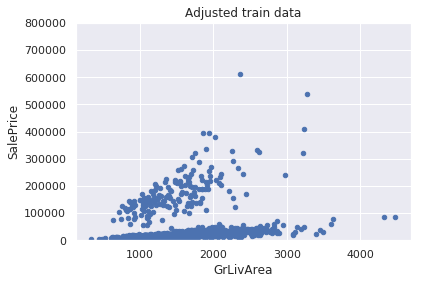

In [26]:
train_data = train_data.drop(train_data[train_data["Id"] == 524].index)
train_data = train_data.drop(train_data[train_data["Id"] == 1299].index)

infl_train_data = infl_train_data.drop(infl_train_data[infl_train_data['Id']==524].index)
infl_train_data = infl_train_data.drop(infl_train_data[infl_train_data['Id']==1299].index)

infl_train_data_25 = infl_train_data_25.drop(infl_train_data_25[infl_train_data_25['Id']==524].index)
infl_train_data_25 = infl_train_data_25.drop(infl_train_data_25[infl_train_data_25['Id']==1299].index)

infl_train_data_50 = infl_train_data_50.drop(infl_train_data_50[infl_train_data_50['Id']==524].index)
infl_train_data_50 = infl_train_data_50.drop(infl_train_data_50[infl_train_data_50['Id']==1299].index)

infl_train_data_75 = infl_train_data_75.drop(infl_train_data_75[infl_train_data_75['Id']==524].index)
infl_train_data_75 = infl_train_data_75.drop(infl_train_data_75[infl_train_data_75['Id']==1299].index)


data = pd.concat([train_data['SalePrice'], train_data[var]], axis=1)
data.plot.scatter(x=var, y='SalePrice', ylim=(0,800000), title='Train data')

infl_data = pd.concat([infl_train_data['SalePrice'], infl_train_data[var]], axis=1)
infl_data.plot.scatter(x=var, y='SalePrice', ylim=(0,800000), title='Adjusted train data')

In [27]:
#One-hot encoding (using categorical data)

cols_with_missing = [col for col in train_data.columns 
                                 if train_data[col].isnull().any()]                                  
candidate_train_predictors = train_data.drop(['Id', 'SalePrice'] + cols_with_missing, axis=1)
candidate_test_predictors = test_data.drop(['Id'] + cols_with_missing, axis=1)

# "cardinality" means the number of unique values in a column.
# We use it as our only way to select categorical columns here. This is convenient, though
# a little arbitrary.
low_cardinality_cols = [cname for cname in candidate_train_predictors.columns if 
                                candidate_train_predictors[cname].nunique() < 10 and
                                candidate_train_predictors[cname].dtype == "object"]
numeric_cols = [cname for cname in candidate_train_predictors.columns if 
                                candidate_train_predictors[cname].dtype in ['int64', 'float64']]
my_cols = low_cardinality_cols + numeric_cols
train_predictors = candidate_train_predictors[my_cols]
test_predictors = candidate_test_predictors[my_cols]

one_hot_encoded_training_predictors = pd.get_dummies(train_predictors)
one_hot_encoded_test_predictors = pd.get_dummies(test_predictors)
final_train, final_test = one_hot_encoded_training_predictors.align(one_hot_encoded_test_predictors,
                                                                    join='left', 
                                                                    axis=1)

#Same for adjusted set:
infl_candidate_train_predictors = infl_train_data.drop(['Id', 'SalePrice'] + cols_with_missing, axis=1)

infl_train_predictors = infl_candidate_train_predictors[my_cols]

infl_one_hot_encoded_training_predictors = pd.get_dummies(infl_train_predictors)
infl_final_train, final_test = infl_one_hot_encoded_training_predictors.align(one_hot_encoded_test_predictors,
                                                                    join='left', 
                                                                    axis=1)

#25:
infl_candidate_train_predictors_25 = infl_train_data_25.drop(['Id', 'SalePrice'] + cols_with_missing, axis=1)

infl_train_predictors_25 = infl_candidate_train_predictors_25[my_cols]

infl_one_hot_encoded_training_predictors_25 = pd.get_dummies(infl_train_predictors_25)
infl_final_train_25, final_test = infl_one_hot_encoded_training_predictors_25.align(one_hot_encoded_test_predictors,
                                                                    join='left', 
                                                                    axis=1)

#50:
infl_candidate_train_predictors_50 = infl_train_data_50.drop(['Id', 'SalePrice'] + cols_with_missing, axis=1)

infl_train_predictors_50 = infl_candidate_train_predictors_50[my_cols]

infl_one_hot_encoded_training_predictors_50 = pd.get_dummies(infl_train_predictors_50)
infl_final_train_50, final_test = infl_one_hot_encoded_training_predictors_50.align(one_hot_encoded_test_predictors,
                                                                    join='left', 
                                                                    axis=1)

#75:
infl_candidate_train_predictors_75 = infl_train_data_75.drop(['Id', 'SalePrice'] + cols_with_missing, axis=1)

infl_train_predictors_75 = infl_candidate_train_predictors_75[my_cols]

infl_one_hot_encoded_training_predictors_75 = pd.get_dummies(infl_train_predictors_75)
infl_final_train_75, final_test = infl_one_hot_encoded_training_predictors_75.align(one_hot_encoded_test_predictors,
                                                                    join='left', 
                                                                    axis=1)

**Now we move to the model**

In [28]:
X = np.array(final_train)
y = train_data.SalePrice

train_X, val_X, train_y, val_y = train_test_split(X, y)

#We are going to compare the original data set, with the adjusted to inflation one:
infl_X = np.array(infl_final_train)
infl_y = infl_train_data.SalePrice

infl_train_X, infl_val_X, infl_train_y, infl_val_y = train_test_split(infl_X, infl_y)

#25%:
infl_X_25 = np.array(infl_final_train_25)
infl_y_25 = infl_train_data_25.SalePrice

infl_train_X_25, infl_val_X_25, infl_train_y_25, infl_val_y_25 = train_test_split(infl_X_25, infl_y_25)

#50%:
infl_X_50 = np.array(infl_final_train_50)
infl_y_50 = infl_train_data_50.SalePrice

infl_train_X_50, infl_val_X_50, infl_train_y_50, infl_val_y_50 = train_test_split(infl_X_50, infl_y_50)

#75%:
infl_X_75 = np.array(infl_final_train_75)
infl_y_75 = infl_train_data_75.SalePrice

infl_train_X_75, infl_val_X_75, infl_train_y_75, infl_val_y_75 = train_test_split(infl_X_75, infl_y_75)

In [29]:
best_learn_rate = 0.2
best_nb_est = 50 
#These come from a previous Kernel, but for the purpose of just testing this, I will keep those values for now

#we extract the year at which the predicted SalePrice have been sold
year_train = train_X[:,[32]]
year_test = val_X[:,[32]]

my_pipeline = make_pipeline(Imputer(), XGBRegressor(n_estimators=best_nb_est, learning_rate = best_learn_rate))

my_pipeline.fit(X,y)
train_y_predicted = my_pipeline.predict(train_X)
val_y_predicted = my_pipeline.predict(val_X)

print('Score on training set:',get_rmse(train_y_predicted,train_y))
print('Score on validation set:',get_rmse(val_y_predicted,val_y))

#Adjusted dataset:
my_pipeline.fit(infl_X,infl_y)
infl_train_y_predicted = my_pipeline.predict(infl_train_X)
infl_val_y_predicted = my_pipeline.predict(infl_val_X)

#25% adjusted dataset:
my_pipeline.fit(infl_X_25,infl_y_25)
infl_train_y_predicted_25 = my_pipeline.predict(infl_train_X_25)
infl_val_y_predicted_25 = my_pipeline.predict(infl_val_X_25)

#50% adjusted dataset:
my_pipeline.fit(infl_X_50,infl_y_50)
infl_train_y_predicted_50 = my_pipeline.predict(infl_train_X_50)
infl_val_y_predicted_50 = my_pipeline.predict(infl_val_X_50)

#75% adjusted dataset:
my_pipeline.fit(infl_X_75,infl_y_75)
infl_train_y_predicted_75 = my_pipeline.predict(infl_train_X_75)
infl_val_y_predicted_75 = my_pipeline.predict(infl_val_X_75)

#Now we need to divide the predictions 'infl_train_y_predicted' by the divid_factor of each year accordingly:
#start by making a copy of the predicted price dataset, just in case:
y_predict = infl_train_y_predicted
y_predict[year_train[:,0] == 2009] = y_predict[year_train[:,0] == 2009]/divid_factor_09
y_predict[year_train[:,0] == 2008] = y_predict[year_train[:,0] == 2008]/divid_factor_08
y_predict[year_train[:,0] == 2007] = y_predict[year_train[:,0] == 2007]/divid_factor_07
y_predict[year_train[:,0] == 2006] = y_predict[year_train[:,0] == 2006]/divid_factor_06
infl_train_y_predicted = y_predict

val_y_predict = infl_val_y_predicted
val_y_predict[year_test[:,0] == 2009] = val_y_predict[year_test[:,0] == 2009]/divid_factor_09
val_y_predict[year_test[:,0] == 2008] = val_y_predict[year_test[:,0] == 2008]/divid_factor_08
val_y_predict[year_test[:,0] == 2007] = val_y_predict[year_test[:,0] == 2007]/divid_factor_07
val_y_predict[year_test[:,0] == 2006] = val_y_predict[year_test[:,0] == 2006]/divid_factor_06
infl_val_y_predicted = val_y_predict

print('Score on adjusted training set:',get_rmse(infl_train_y_predicted,infl_train_y))
print('Score on adjusted validation set:',get_rmse(infl_val_y_predicted,infl_val_y))

#25%:
y_predict_25 = infl_train_y_predicted_25
y_predict_25[year_train[:,0] == 2009] = y_predict_25[year_train[:,0] == 2009]/divid_factor_09_25
y_predict_25[year_train[:,0] == 2008] = y_predict_25[year_train[:,0] == 2008]/divid_factor_08_25
y_predict_25[year_train[:,0] == 2007] = y_predict_25[year_train[:,0] == 2007]/divid_factor_07_25
y_predict_25[year_train[:,0] == 2006] = y_predict_25[year_train[:,0] == 2006]/divid_factor_06_25
infl_train_y_predicted_25 = y_predict_25

val_y_predict_25 = infl_val_y_predicted_25
val_y_predict_25[year_test[:,0] == 2009] = val_y_predict_25[year_test[:,0] == 2009]/divid_factor_09_25
val_y_predict_25[year_test[:,0] == 2008] = val_y_predict_25[year_test[:,0] == 2008]/divid_factor_08_25
val_y_predict_25[year_test[:,0] == 2007] = val_y_predict_25[year_test[:,0] == 2007]/divid_factor_07_25
val_y_predict_25[year_test[:,0] == 2006] = val_y_predict_25[year_test[:,0] == 2006]/divid_factor_06_25
infl_val_y_predicted_25 = val_y_predict_25

print('Score on 25% adjusted training set:',get_rmse(infl_train_y_predicted_25,infl_train_y_25))
print('Score on 25% adjusted validation set:',get_rmse(infl_val_y_predicted_25,infl_val_y_25))

/opt/conda/lib/python3.6/site-packages/sklearn/utils/deprecation.py:58: DeprecationWarning: Class Imputer is deprecated; Imputer was deprecated in version 0.20 and will be removed in 0.22. Import impute.SimpleImputer from sklearn instead.
  warnings.warn(msg, category=DeprecationWarning)


Score on training set: 0.06716075911443117
Score on validation set: 0.06764076355089116
Score on adjusted training set: 0.09232174158545615
Score on adjusted validation set: 0.09877028621662694
Score on 25% adjusted training set: 1.2080875373719417
Score on 25% adjusted validation set: 1.1767520415147903


This priced are baed on the 2010 USD. Wee need to now convert back to their respective years. To do so, we are going to need to get 'YrSold' by index, because the predicted prices are just situated in an array with no index or year info. For this, we basically need to get an array with just 'YrSold', since it will be in the same order as our predicted prive array.

Then, we need to divide the predicted SalePrice by the ratio of USD value depending on the YrSold

Score on training set is better than previous Kernel (0.06955...)

Score on validation set is worse than previous Kernel (0.06391...)

We can notice a very slight improvement when adjusting for inflation, which is good news!

In [30]:
predictions = my_pipeline.predict(final_test)
output = pd.DataFrame({'Id': test_data.Id,
                       'SalePrice': predictions})

output.to_csv('submission.csv', index=False)